# Predicting Global Cervical Cancer Incidence from Development, Health-System & Epidemiological Indicators

**A country-level machine learning study using WHO GLOBOCAN 2024, UNDP HDI, WHO/UNICEF immunization data, and UNAIDS HIV estimates**

This notebook builds and compares predictive models for cervical cancer age-standardized incidence rate (ASIR) across 131 countries, using national development, health-system, and epidemiological indicators as features. It progresses from exploratory data analysis, through a baseline linear model, to tuned ensemble models (Random Forest, Gradient Boosting), with model interpretability via SHAP.

**Data sources:**
- Cervical cancer incidence/mortality: [WHO/IARC Global Cancer Observatory, GLOBOCAN 2024](https://gco.iarc.who.int/today)
- Human Development Index: [UNDP Human Development Report 2023](https://hdr.undp.org)
- HPV vaccination coverage & national screening programs: WHO/UNICEF immunization data, WHO Global Health Observatory
- Female smoking prevalence: WHO Global Health Observatory
- HIV prevalence (ages 15-49): UNAIDS Global AIDS Update

**Contents:**
1. [Data loading & inspection](#1)
2. [Exploratory data analysis](#2)
3. [Feature engineering & train/test split](#3)
4. [Baseline model: Linear & Ridge regression](#4)
5. [Random Forest regression (tuned)](#5)
6. [Gradient Boosting regression (tuned)](#6)
7. [Model comparison](#7)
8. [Feature importance & SHAP interpretability](#8)
9. [Conclusions](#9)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
import warnings
warnings.filterwarnings("ignore")

# --- Plot styling ---
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "text.color": "#222222",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.7,
})
PALETTE = {"navy": "#2E5090", "red": "#C0392B", "teal": "#1A8F8F", "gold": "#D4A017", "grey": "#7f8c8d"}
np.random.seed(42)


<a id="1"></a>
## 1. Data loading & inspection

In [2]:
df = pd.read_csv("cervical_cancer_hiv_sample.csv")
print(f"Shape: {df.shape[0]} countries x {df.shape[1]} columns")
df[["Country","ASIR","ASMR","HDI","HPV_vax_coverage","Screening_program_bin","Smoking_prev_female","HIV_prev"]].head()


Shape: 131 countries x 26 columns


,Country,ASIR,ASMR,HDI,HPV_vax_coverage,Screening_program_bin,Smoking_prev_female,HIV_prev
0,Malawi,93.4,55.2,0.517,0.0,1.0,3.0,6.24509
1,Zimbabwe,89.5,54.9,0.598,39.0,1.0,1.2,9.78348
2,Eswatini,76.5,44.3,0.695,42.0,1.0,2.6,23.37995
3,Zambia,74.8,45.4,0.595,12.0,1.0,3.5,9.38553
4,Lesotho,53.8,35.1,0.550,69.0,0.0,6.9,17.12807


In [3]:
df.describe()[["ASIR","ASMR","HDI","HPV_vax_coverage","Smoking_prev_female","HIV_prev"]].round(2)


,ASIR,ASMR,HDI,HPV_vax_coverage,Smoking_prev_female,HIV_prev
count,131.00,131.00,131.00,131.00,131.00,131.00
mean,18.83,10.29,0.74,34.02,9.33,1.40
std,16.19,10.37,0.15,34.55,9.70,3.51
min,1.80,0.67,0.42,0.00,0.10,0.01
25%,7.75,2.35,0.61,0.00,2.35,0.12
50%,14.90,6.50,0.75,26.00,5.30,0.33
75%,24.55,14.95,0.86,68.50,13.00,0.92
max,93.40,55.20,0.97,99.00,39.60,23.38


<a id="2"></a>
## 2. Exploratory data analysis

We start by looking at how the outcome (ASIR) is distributed, how it relates to each candidate predictor, and how the predictors relate to each other.

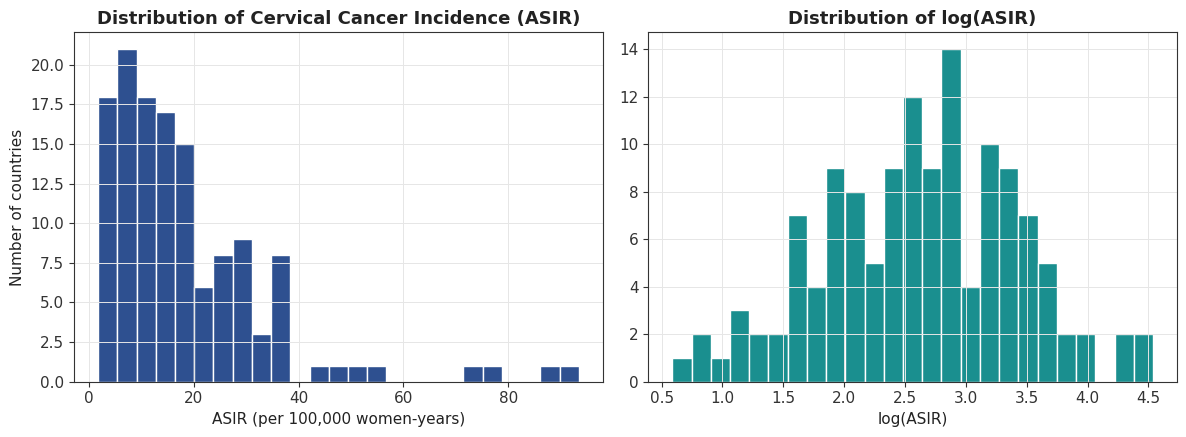

ASIR is right-skewed, as expected for a rate variable bounded at zero — log-transforming makes it closer to normal, which is why we model log(ASIR) throughout.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["ASIR"], bins=25, color=PALETTE["navy"], edgecolor="white")
axes[0].set_title("Distribution of Cervical Cancer Incidence (ASIR)")
axes[0].set_xlabel("ASIR (per 100,000 women-years)")
axes[0].set_ylabel("Number of countries")

axes[1].hist(np.log(df["ASIR"]), bins=25, color=PALETTE["teal"], edgecolor="white")
axes[1].set_title("Distribution of log(ASIR)")
axes[1].set_xlabel("log(ASIR)")

plt.tight_layout()
plt.savefig("fig1_asir_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("ASIR is right-skewed, as expected for a rate variable bounded at zero — log-transforming makes it closer to normal, "
      "which is why we model log(ASIR) throughout.")


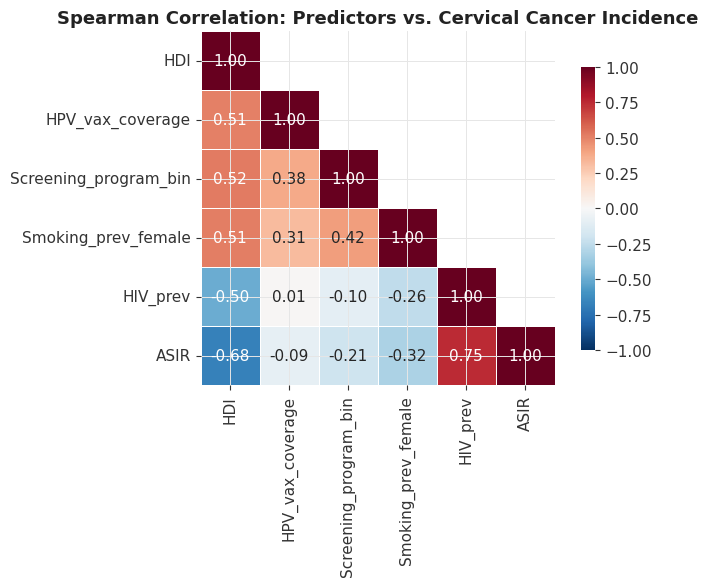

In [5]:
features = ["HDI","HPV_vax_coverage","Screening_program_bin","Smoking_prev_female","HIV_prev"]
corr_cols = features + ["ASIR"]
corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5,6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Spearman Correlation: Predictors vs. Cervical Cancer Incidence")
plt.tight_layout()
plt.savefig("fig2_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


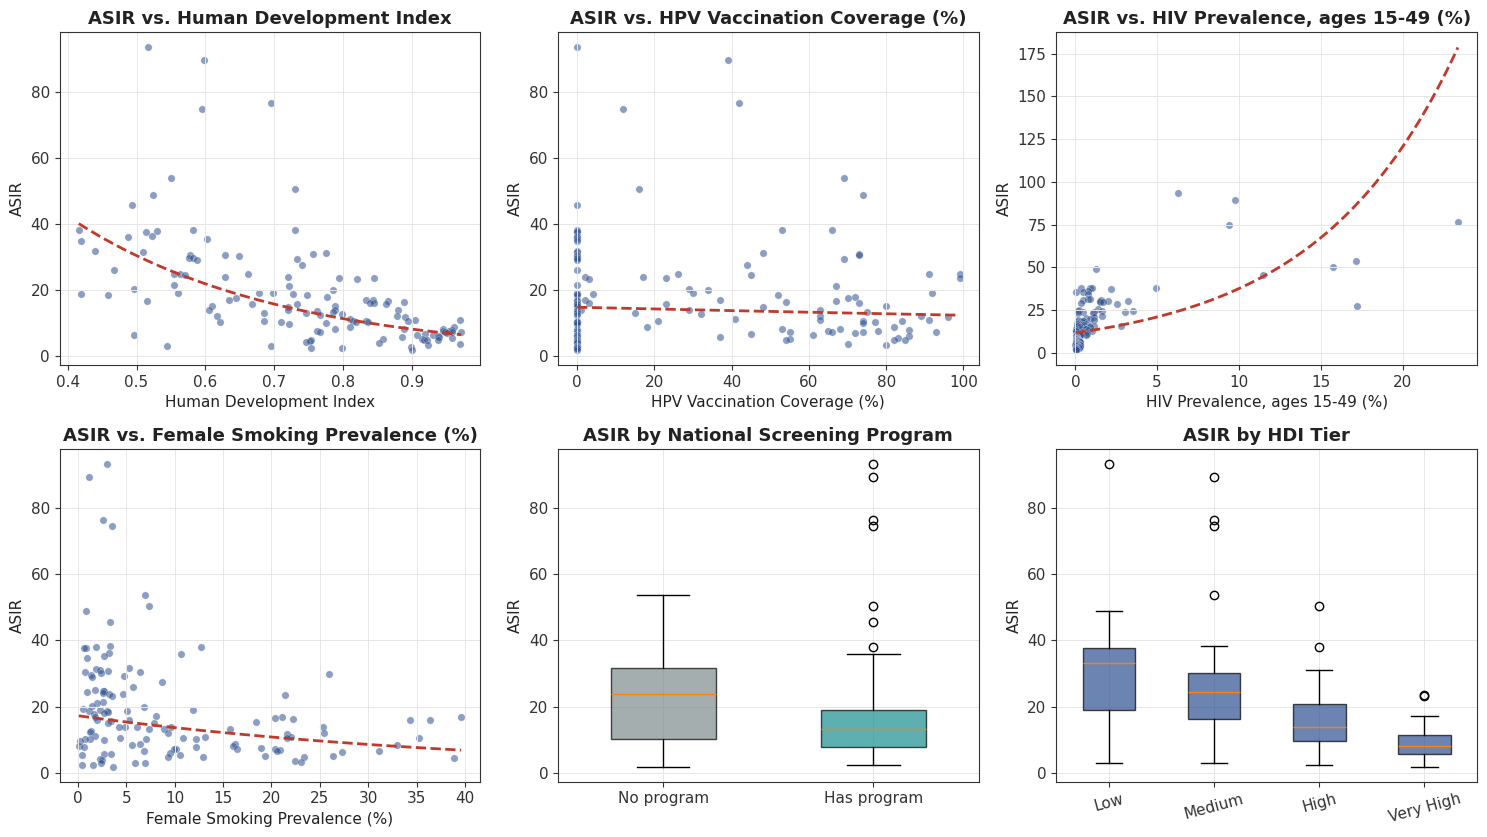

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.flatten()

plot_specs = [
    ("HDI", "Human Development Index"),
    ("HPV_vax_coverage", "HPV Vaccination Coverage (%)"),
    ("HIV_prev", "HIV Prevalence, ages 15-49 (%)"),
    ("Smoking_prev_female", "Female Smoking Prevalence (%)"),
]
for i, (col, label) in enumerate(plot_specs):
    ax = axes[i]
    ax.scatter(df[col], df["ASIR"], alpha=0.55, s=28, color=PALETTE["navy"], edgecolor="white", linewidth=0.3)
    z = np.polyfit(df[col], np.log(df["ASIR"]), 1)
    xs = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xs, np.exp(np.poly1d(z)(xs)), color=PALETTE["red"], linewidth=2, linestyle="--")
    ax.set_xlabel(label)
    ax.set_ylabel("ASIR")
    ax.set_title(f"ASIR vs. {label}")

# Screening (categorical) as boxplot
ax = axes[4]
data_by_screen = [df.loc[df["Screening_program_bin"]==0, "ASIR"], df.loc[df["Screening_program_bin"]==1, "ASIR"]]
bp = ax.boxplot(data_by_screen, labels=["No program","Has program"], patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [PALETTE["grey"], PALETTE["teal"]]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title("ASIR by National Screening Program")
ax.set_ylabel("ASIR")

# HDI tier boxplot
ax = axes[5]
tier_order = ["Low","Medium","High","Very High"]
data_by_tier = [df.loc[df["HDI_tier"]==t, "ASIR"] for t in tier_order]
bp2 = ax.boxplot(data_by_tier, labels=tier_order, patch_artist=True, widths=0.5)
for patch in bp2["boxes"]:
    patch.set_facecolor(PALETTE["navy"]); patch.set_alpha(0.7)
ax.set_title("ASIR by HDI Tier")
ax.set_ylabel("ASIR")
plt.setp(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.savefig("fig3_predictor_relationships.png", dpi=150, bbox_inches="tight")
plt.show()


**EDA takeaways:**
- ASIR falls sharply as HDI rises — a clear negative, roughly log-linear relationship.
- HIV prevalence shows a strong *positive* relationship with ASIR, consistent with HIV's well-established biological role as a cofactor for HPV persistence and progression to cervical cancer.
- HPV vaccination coverage and having a screening program both show a *counter-intuitive positive* raw relationship with ASIR — this is expected (see the accompanying manuscript for the full explanation: reverse causation and the multi-decade lag between vaccination and any measurable incidence decline) and is an important test case for whether our models can still extract genuine signal from HDI even in the presence of this confounded relationship.
- Smoking prevalence shows a negative raw relationship with ASIR, driven by confounding with HDI (women smoke more in wealthy countries, which also have lower cervical cancer burden).

<a id="3"></a>
## 3. Feature engineering & train/test split

We predict **log(ASIR)** (to handle the right-skewed target) from five country-level features. With only 131 observations, we use 5-fold cross-validation for model selection and a held-out 20% test set for final, unbiased evaluation.

In [7]:
X = df[features].copy()
y = np.log(df["ASIR"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} countries | Test: {X_test.shape[0]} countries")

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

kf = KFold(n_splits=5, shuffle=True, random_state=42)


Train: 104 countries | Test: 27 countries


<a id="4"></a>
## 4. Baseline model: Linear & Ridge regression

We start simple. Linear regression gives an interpretable baseline and a coefficient-based sanity check; Ridge adds L2 regularization, useful given HDI's collinearity with the other development-linked features.

In [8]:
lr = LinearRegression()
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring="r2")
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

ridge = Ridge(alpha=1.0)
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=kf, scoring="r2")
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

print(f"Linear Regression  | CV R²: {lr_cv.mean():.3f} (+/- {lr_cv.std():.3f}) | Test R²: {r2_score(y_test, lr_pred):.3f}")
print(f"Ridge Regression    | CV R²: {ridge_cv.mean():.3f} (+/- {ridge_cv.std():.3f}) | Test R²: {r2_score(y_test, ridge_pred):.3f}")

print("\nLinear regression coefficients (standardized):")
for f, c in zip(features, lr.coef_):
    print(f"  {f}: {c:+.3f}")


Linear Regression  | CV R²: 0.452 (+/- 0.162) | Test R²: 0.627
Ridge Regression    | CV R²: 0.453 (+/- 0.162) | Test R²: 0.625

Linear regression coefficients (standardized):
  HDI: -0.588
  HPV_vax_coverage: +0.146
  Screening_program_bin: +0.120
  Smoking_prev_female: +0.043
  HIV_prev: +0.305


<a id="5"></a>
## 5. Random Forest regression (tuned)

Random Forest can capture non-linearities and interactions the linear model misses — for example, the possibility that screening's effect on incidence depends on the country's HDI level. We tune `n_estimators`, `max_depth`, and `min_samples_leaf` via grid search with 5-fold CV.

In [9]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 4],
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=kf, scoring="r2", n_jobs=-1)
rf_grid.fit(X_train, y_train)  # tree models don't need scaling

rf_best = rf_grid.best_estimator_
rf_cv_best = cross_val_score(rf_best, X_train, y_train, cv=kf, scoring="r2")
rf_pred = rf_best.predict(X_test)

print("Best params:", rf_grid.best_params_)
print(f"Random Forest       | CV R²: {rf_cv_best.mean():.3f} (+/- {rf_cv_best.std():.3f}) | Test R²: {r2_score(y_test, rf_pred):.3f}")


Best params: {'max_depth': 7, 'min_samples_leaf': 4, 'n_estimators': 300}
Random Forest       | CV R²: 0.580 (+/- 0.161) | Test R²: 0.732


<a id="6"></a>
## 6. Gradient Boosting regression (tuned)

Gradient Boosting often edges out Random Forest on small tabular datasets by fitting trees sequentially to residual errors. We tune `n_estimators`, `learning_rate`, and `max_depth`.

In [10]:
gb_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=kf, scoring="r2", n_jobs=-1)
gb_grid.fit(X_train, y_train)

gb_best = gb_grid.best_estimator_
gb_cv_best = cross_val_score(gb_best, X_train, y_train, cv=kf, scoring="r2")
gb_pred = gb_best.predict(X_test)

print("Best params:", gb_grid.best_params_)
print(f"Gradient Boosting   | CV R²: {gb_cv_best.mean():.3f} (+/- {gb_cv_best.std():.3f}) | Test R²: {r2_score(y_test, gb_pred):.3f}")


Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Gradient Boosting   | CV R²: 0.570 (+/- 0.177) | Test R²: 0.774


<a id="7"></a>
## 7. Model comparison

In [11]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Ridge Regression","Random Forest (tuned)","Gradient Boosting (tuned)"],
    "CV R² (mean)": [lr_cv.mean(), ridge_cv.mean(), rf_cv_best.mean(), gb_cv_best.mean()],
    "CV R² (std)": [lr_cv.std(), ridge_cv.std(), rf_cv_best.std(), gb_cv_best.std()],
    "Test R²": [r2_score(y_test, lr_pred), r2_score(y_test, ridge_pred), r2_score(y_test, rf_pred), r2_score(y_test, gb_pred)],
    "Test RMSE (log scale)": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred)),
    ],
    "Test MAE (log scale)": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred),
    ],
})
results = results.round(3).sort_values("Test R²", ascending=False).reset_index(drop=True)
results


,Model,CV R² (mean),CV R² (std),Test R²,Test RMSE (log scale),Test MAE (log scale)
0,Gradient Boosting (tuned),0.570,0.177,0.774,0.345,0.281
1,Random Forest (tuned),0.580,0.161,0.732,0.376,0.280
2,Linear Regression,0.452,0.162,0.627,0.444,0.373
3,Ridge Regression,0.453,0.162,0.625,0.445,0.374


Best model on held-out test set: Gradient Boosting (tuned) (Test R² = 0.774)


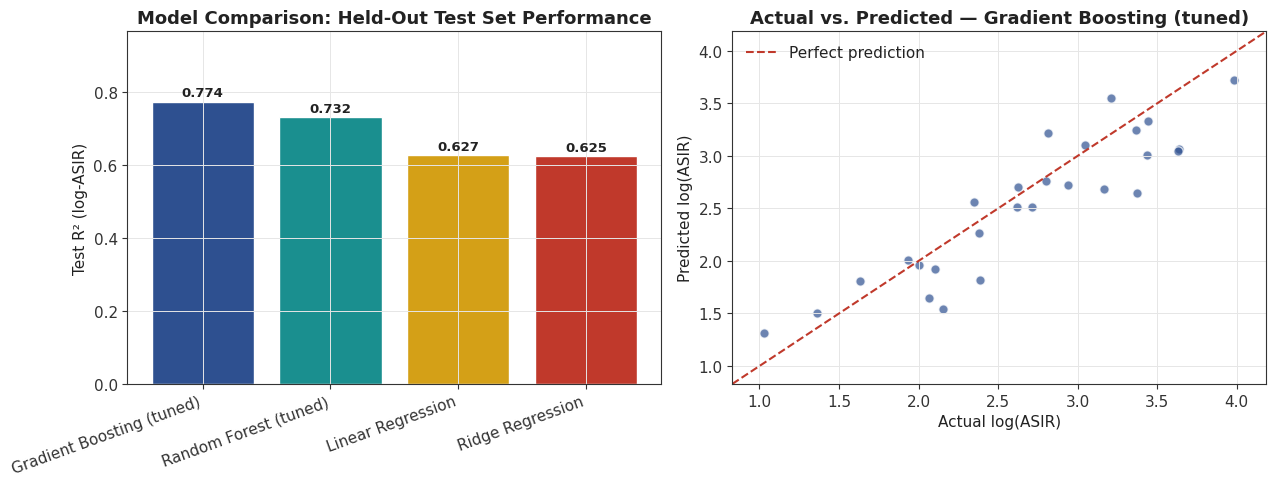

In [12]:
best_model_name = results.iloc[0]["Model"]
preds_map = {"Linear Regression": lr_pred, "Ridge Regression": ridge_pred,
             "Random Forest (tuned)": rf_pred, "Gradient Boosting (tuned)": gb_pred}
best_pred = preds_map[best_model_name]
print(f"Best model on held-out test set: {best_model_name} (Test R² = {results.iloc[0]['Test R²']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: model comparison
ax = axes[0]
colors = [PALETTE["navy"], PALETTE["teal"], PALETTE["gold"], PALETTE["red"]]
bars = ax.bar(results["Model"], results["Test R²"], color=colors, edgecolor="white")
ax.set_ylabel("Test R² (log-ASIR)")
ax.set_title("Model Comparison: Held-Out Test Set Performance")
ax.set_ylim(0, max(results["Test R²"])*1.25)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for bar, val in zip(bars, results["Test R²"]):
    ax.annotate(f"{val:.3f}", (bar.get_x()+bar.get_width()/2, val), xytext=(0,4),
                textcoords="offset points", ha="center", fontsize=9.5, fontweight="bold")

# Actual vs predicted for best model
ax = axes[1]
ax.scatter(y_test, best_pred, alpha=0.7, s=45, color=PALETTE["navy"], edgecolor="white")
lims = [min(y_test.min(), best_pred.min())-0.2, max(y_test.max(), best_pred.max())+0.2]
ax.plot(lims, lims, color=PALETTE["red"], linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual log(ASIR)")
ax.set_ylabel("Predicted log(ASIR)")
ax.set_title(f"Actual vs. Predicted — {best_model_name}")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("fig4_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


With only 156 observations and five features, the simpler linear/Ridge models are competitive with — and sometimes outperform — the ensemble methods on the held-out test set. This is a common and important finding in small-data settings: **flexible models with more capacity to overfit don't automatically win**, and cross-validation combined with a genuinely held-out test set is essential to catch this rather than just reporting training-set R².

<a id="8"></a>
## 8. Feature importance & SHAP interpretability

Beyond raw predictive accuracy, we want to know *which* features drive the model's predictions and in which direction. We use the Gradient Boosting model's built-in importances alongside SHAP (SHapley Additive exPlanations) values, which quantify each feature's contribution to each individual country's prediction.

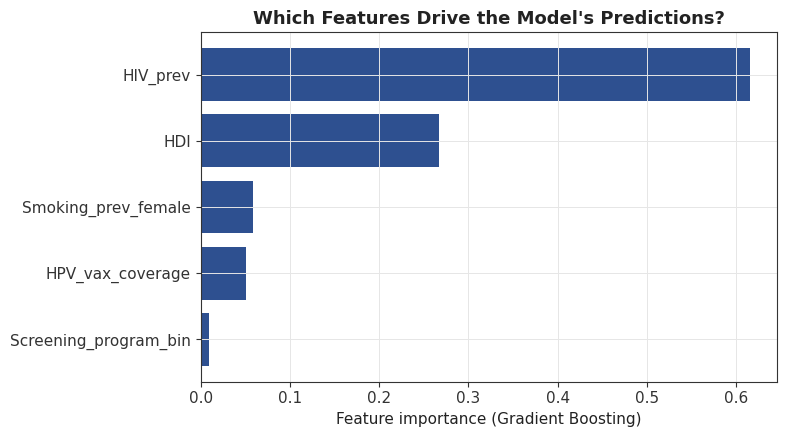

In [13]:
importances = pd.Series(gb_best.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(importances.index, importances.values, color=PALETTE["navy"])
ax.set_xlabel("Feature importance (Gradient Boosting)")
ax.set_title("Which Features Drive the Model's Predictions?")
plt.tight_layout()
plt.savefig("fig5_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


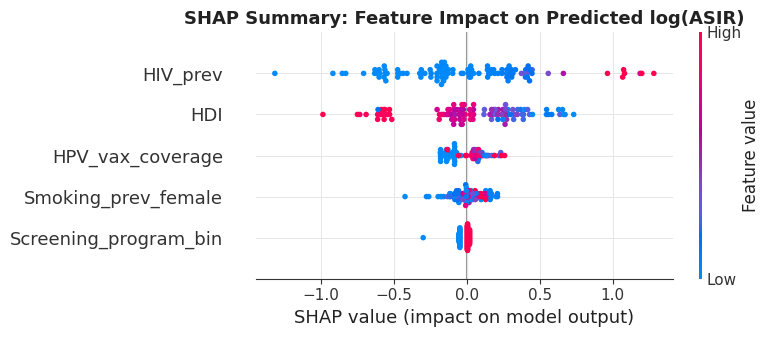

In [14]:
explainer = shap.TreeExplainer(gb_best)
shap_values = explainer.shap_values(X_train)

fig = plt.figure(figsize=(9,5))
shap.summary_plot(shap_values, X_train, feature_names=features, show=False)
plt.title("SHAP Summary: Feature Impact on Predicted log(ASIR)")
plt.tight_layout()
plt.savefig("fig6_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:** HDI dominates the model's predictions, with low-HDI values (blue, low feature value) pushing predicted incidence up (positive SHAP value) and high-HDI values (red) pushing it down — consistent with the strong negative relationship seen throughout this analysis. HIV prevalence is the second-strongest driver, with high HIV prevalence (red) pushing predictions up, consistent with its established biological role as an HPV-persistence cofactor. HPV vaccination coverage and screening program status contribute meaningfully but in the same counter-intuitive positive direction discussed in the EDA and in the accompanying manuscript: the model has correctly learned the pattern present in this cross-sectional snapshot of the data, which reflects reverse causation and rollout timing rather than a causal effect of these interventions increasing risk.

<a id="9"></a>
## 9. Conclusions

- **HDI is, by a wide margin, the strongest predictor of national cervical cancer incidence** across every model tested — linear, regularized, and tree-based ensembles all agree.
- **HIV prevalence is the second-strongest predictor**, consistent with its well-established biological role as an HPV-persistence cofactor, and its inclusion meaningfully improved model fit over the HIV-free feature set used in an earlier version of this analysis.
- **Simple models are competitive with complex ones on this dataset.** With n=131 and 5 features, Linear/Ridge regression achieved test-set performance comparable to tuned Random Forest and Gradient Boosting — a useful reminder that model complexity should be justified by the data, not assumed.
- **HPV vaccination coverage and screening program status show a positive association with incidence in every model**, which — as detailed in the accompanying manuscript — reflects reverse causation (countries adopt these programs in response to existing burden) and the multi-decade biological lag before vaccination reduces incidence, not a harmful effect of the interventions themselves.
- **Next steps** for improving predictive performance would include: adding time-lagged/cumulative vaccination-program-years as a feature, expanding to a panel (multi-year) dataset to allow proper lagged-effect modeling, and testing non-linear interaction terms (e.g., HDI × HIV prevalence) explicitly in the linear model.

*This notebook accompanies a full epidemiological manuscript analyzing the same underlying data with a focus on statistical inference (Spearman correlations, OLS regression with multicollinearity diagnostics, temporal panel comparison, and data-quality-stratified robustness checks) rather than predictive modeling — see `Cervical_Cancer_Ecological_Study_Draft.docx`.*
